## 01. Data Ingestion
- Loading the raw dataset and performing an initial inspection to understand its structure, size and columns.

- "low_memory=False" ensures pandas reads the CSV in one go to guess consistent column types instead of saving memory, and "nrows=50000" limits loading to the first 50,000 rows to save memory and speed up analysis.

In [207]:
import pandas as pd

In [209]:
df = pd.read_csv("accepted_2007_to_2018Q4.csv", low_memory=False, nrows=50000)

df.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
6,68476668,NaN,20000.0,20000.0,20000.0,36 months,9.17,637.58,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
7,67275481,NaN,20000.0,20000.0,20000.0,36 months,8.49,631.26,B,B1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
8,68466926,NaN,10000.0,10000.0,10000.0,36 months,6.49,306.45,A,A2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9,68616873,NaN,8000.0,8000.0,8000.0,36 months,11.48,263.74,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 57.6+ MB


In [211]:
df.shape

(50000, 151)

In [212]:
print(df.isnull().sum().sort_values(ascending=False).head(20))

sec_app_open_acc                              50000
member_id                                     50000
revol_bal_joint                               50000
sec_app_fico_range_low                        50000
sec_app_fico_range_high                       50000
sec_app_earliest_cr_line                      50000
sec_app_inq_last_6mths                        50000
sec_app_mort_acc                              50000
sec_app_revol_util                            50000
sec_app_open_act_il                           50000
sec_app_num_rev_accts                         50000
sec_app_chargeoff_within_12_mths              50000
sec_app_collections_12_mths_ex_med            50000
sec_app_mths_since_last_major_derog           50000
desc                                          49997
dti_joint                                     49765
verification_status_joint                     49764
annual_inc_joint                              49764
orig_projected_additional_accrued_interest    49675
hardship_amo

In [213]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [219]:
df.describe(include='all')

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
count,5.000000e+04,0.0,50000.000000,50000.000000,50000.000000,50000,50000.000000,50000.000000,50000,50000,...,406.000000,406.000000,50000,50000,1537,1537,1537,1537.000000,1537.000000,1537.000000
unique,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,7,35,...,NaN,NaN,1,2,30,3,35,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,36 months,NaN,NaN,B,C1,...,NaN,NaN,Cash,N,Nov-2018,COMPLETE,Oct-2017,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,34177,NaN,NaN,15264,3309,...,NaN,NaN,50000,48463,121,654,100,NaN,NaN,NaN
mean,6.670963e+07,NaN,15019.359500,15019.359500,15011.823500,NaN,12.234782,434.098806,NaN,NaN,...,10431.307488,191.497044,NaN,NaN,NaN,NaN,NaN,5009.780507,47.000150,13.716331
std,1.942339e+06,NaN,8676.103295,8676.103295,8671.131769,NaN,4.191338,247.494017,NaN,NaN,...,6537.325974,187.127673,NaN,NaN,NaN,NaN,NaN,3567.857376,5.367391,7.477062
min,6.702500e+04,NaN,1000.000000,1000.000000,950.000000,NaN,5.320000,14.770000,NaN,NaN,...,55.730000,0.050000,NaN,NaN,NaN,NaN,NaN,186.000000,30.000000,0.000000
25%,6.594684e+07,NaN,8000.000000,8000.000000,8000.000000,NaN,9.170000,255.040000,NaN,NaN,...,5190.170000,46.355000,NaN,NaN,NaN,NaN,NaN,2110.000000,45.000000,8.000000
50%,6.654286e+07,NaN,14000.000000,14000.000000,13900.000000,NaN,11.990000,378.150000,NaN,NaN,...,9388.780000,130.515000,NaN,NaN,NaN,NaN,NaN,4292.650000,45.000000,14.000000
75%,6.744762e+07,NaN,20000.000000,20000.000000,20000.000000,NaN,14.480000,573.702500,NaN,NaN,...,15055.480000,284.637500,NaN,NaN,NaN,NaN,NaN,7024.000000,50.000000,18.000000


In [220]:
all_columns = df.columns.tolist()
len(all_columns)  # How many columns total
print(all_columns)

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

## 02. Column Selection
- Retaining only the columns relevant to borrower risk and loan pricing.
- Dropping admin columns such as "id', 'url", and separating out columns that could cause data leakage

In [224]:
#keeping only the most useful columns
loan_info = ['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'installment']
borrower_info = ['emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti']
credit_info = ['fico_range_low', 'fico_range_high', 'open_acc', 'revol_bal', 'revol_util', 'delinq_2yrs', 'total_acc', 'pub_rec']
target_variable = ['loan_status']
payment_info = ['total_pymnt', 'total_rec_prncp', 'recoveries', 'collection_recovery_fee']
                

columns_to_keep = loan_info + borrower_info + credit_info + target_variable + payment_info
df_cleaned = df[columns_to_keep]
print(df_cleaned.head(10))


   loan_amnt        term  int_rate grade sub_grade  installment  \
0     3600.0   36 months     13.99     C        C4       123.03   
1    24700.0   36 months     11.99     C        C1       820.28   
2    20000.0   60 months     10.78     B        B4       432.66   
3    35000.0   60 months     14.85     C        C5       829.90   
4    10400.0   60 months     22.45     F        F1       289.91   
5    11950.0   36 months     13.44     C        C3       405.18   
6    20000.0   36 months      9.17     B        B2       637.58   
7    20000.0   36 months      8.49     B        B1       631.26   
8    10000.0   36 months      6.49     A        A2       306.45   
9     8000.0   36 months     11.48     B        B5       263.74   

                                 emp_title emp_length home_ownership  \
0                                  leadman  10+ years       MORTGAGE   
1                                 Engineer  10+ years       MORTGAGE   
2                             truck driver  10

## 03. Data Cleaning & Preprocessing
Handling missing values, fixing data types, renaming columns for clarify and standardising formats. 

In [227]:
clean_columns = df_cleaned.columns.to_list()
print(clean_columns)

['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'installment', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'fico_range_low', 'fico_range_high', 'open_acc', 'revol_bal', 'revol_util', 'delinq_2yrs', 'total_acc', 'pub_rec', 'loan_status', 'total_pymnt', 'total_rec_prncp', 'recoveries', 'collection_recovery_fee']


In [229]:
df_cleaned.isnull().sum().sort_values(ascending = False)

emp_title                  2995
emp_length                 2989
revol_util                   24
dti                           1
loan_amnt                     0
open_acc                      0
recoveries                    0
total_rec_prncp               0
total_pymnt                   0
loan_status                   0
pub_rec                       0
total_acc                     0
delinq_2yrs                   0
revol_bal                     0
fico_range_low                0
fico_range_high               0
term                          0
purpose                       0
verification_status           0
annual_inc                    0
home_ownership                0
installment                   0
sub_grade                     0
grade                         0
int_rate                      0
collection_recovery_fee       0
dtype: int64

In [231]:
#creating a copy of the cleaned dataframe
df_cleaned["emp_title"].describe()
df_cleaned_copy = df_cleaned.copy()

In [233]:
#dropping the entries with 'na'.
df_cleaned_copy["emp_title"] = df_cleaned_copy['emp_title'].fillna('unknown')

In [235]:
df_cleaned_copy.dtypes

loan_amnt                  float64
term                        object
int_rate                   float64
grade                       object
sub_grade                   object
installment                float64
emp_title                   object
emp_length                  object
home_ownership              object
annual_inc                 float64
verification_status         object
purpose                     object
dti                        float64
fico_range_low             float64
fico_range_high            float64
open_acc                   float64
revol_bal                  float64
revol_util                 float64
delinq_2yrs                float64
total_acc                  float64
pub_rec                    float64
loan_status                 object
total_pymnt                float64
total_rec_prncp            float64
recoveries                 float64
collection_recovery_fee    float64
dtype: object

In [237]:
#changing data types. 'term' and 'employment length' need to be changed to a whole number
df_cleaned_copy.rename(columns={'term': 'term (months)', 'emp_length': 'emp_length (years)'}, inplace=True)
df_cleaned_copy.columns.to_list()

['loan_amnt',
 'term (months)',
 'int_rate',
 'grade',
 'sub_grade',
 'installment',
 'emp_title',
 'emp_length (years)',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'purpose',
 'dti',
 'fico_range_low',
 'fico_range_high',
 'open_acc',
 'revol_bal',
 'revol_util',
 'delinq_2yrs',
 'total_acc',
 'pub_rec',
 'loan_status',
 'total_pymnt',
 'total_rec_prncp',
 'recoveries',
 'collection_recovery_fee']

In [239]:
df_cleaned_copy["term (months)"] = df_cleaned_copy["term (months)"].str.extract(r"(\d+)").astype(int)


In [241]:
df_cleaned_copy["emp_length (years)"] = df_cleaned_copy["emp_length (years)"].str.extract(r"(\d+)").astype(float)
df_cleaned_copy["emp_length (years)"] = df_cleaned_copy["emp_length (years)"].fillna(df_cleaned_copy["emp_length (years)"].median())

In [243]:
df_cleaned_copy["dti"] = df_cleaned_copy["dti"].fillna(df_cleaned_copy["dti"].median())

In [245]:
df_cleaned_copy["revol_util"] = df_cleaned_copy["revol_util"].fillna(df_cleaned_copy["revol_util"].median())

In [247]:
df_cleaned_copy[["total_acc", "pub_rec", "delinq_2yrs", "open_acc"]] = df_cleaned_copy[["total_acc", "pub_rec", "delinq_2yrs", "open_acc"]].astype("Int64")

In [249]:
df_cleaned_copy['total_pymnt'] = df_cleaned_copy['total_pymnt'].round(2)

In [251]:
df_cleaned_copy["emp_title"] = df_cleaned_copy["emp_title"].str.capitalize()

In [253]:
df_cleaned_copy["home_ownership"].value_counts()

home_ownership
MORTGAGE    24586
RENT        19660
OWN          5753
ANY             1
Name: count, dtype: int64

In [255]:
df_cleaned_copy["home_ownership"] = df_cleaned_copy["home_ownership"].str.capitalize()
df_cleaned_copy["home_ownership"] = df_cleaned_copy["home_ownership"].replace({
    "ANY": "OTHER",
})

In [257]:
print(df_cleaned_copy.head(10))

   loan_amnt  term (months)  int_rate grade sub_grade  installment  \
0     3600.0             36     13.99     C        C4       123.03   
1    24700.0             36     11.99     C        C1       820.28   
2    20000.0             60     10.78     B        B4       432.66   
3    35000.0             60     14.85     C        C5       829.90   
4    10400.0             60     22.45     F        F1       289.91   
5    11950.0             36     13.44     C        C3       405.18   
6    20000.0             36      9.17     B        B2       637.58   
7    20000.0             36      8.49     B        B1       631.26   
8    10000.0             36      6.49     A        A2       306.45   
9     8000.0             36     11.48     B        B5       263.74   

                                 emp_title  emp_length (years) home_ownership  \
0                                  Leadman                10.0       Mortgage   
1                                 Engineer                10.0     

## 04. Feature Engineering
Creating new variables that give the model more predictive signal 
than the raw columns alone provide.

### FICO Average (`fico_avg`)
Taking the midpoint of `fico_range_low` and `fico_range_high` to create a single 
continuous feature. 

In [261]:
df_cleaned_copy["fico_avg"] = (
    df_cleaned_copy["fico_range_low"] + df_cleaned_copy["fico_range_high"]
) / 2

In [263]:
df_cleaned_copy["loan_status"].value_counts()

loan_status
Fully Paid            34978
Charged Off            9027
Current                5610
Late (31-120 days)      246
In Grace Period         100
Late (16-30 days)        38
Default                   1
Name: count, dtype: int64

### Target Variable - Default Flag (`default`)

Loans are classified as defaulted (1) if their status is 
"Charged Off" or "Default", and as repaid (0) if "Fully Paid". 
All other statuses — "Current", "Late", "In Grace Period" — 
are excluded because their final outcome is still unknown. 
Including them would mean training the model on incomplete 
information.

In [266]:
df_cleaned_copy = df_cleaned_copy[df_cleaned_copy['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])]
df_cleaned_copy["default"] = df_cleaned_copy["loan_status"].isin(['Charged Off', 'Default']).astype(int)
df_cleaned_copy["default"].value_counts()

#1 represents a loan that was either Charged Off or Default, and 0 represents Fully Paid.

default
0    34978
1     9028
Name: count, dtype: int64

### Loan-to-Income Ratio (`loan_to_income_ratio (%)`)
The loan-to-income ratio expresses the loan as a percentage 
of annual income, making the relative financial burden explicit. 

In [269]:
#Loan-to-income ratio

df_cleaned_copy['loan_to_income_ratio (%)'] = round(df_cleaned_copy['loan_amnt']/ df_cleaned_copy['annual_inc']*100, 2)

df_cleaned_copy['loan_to_income_ratio (%)'].head(10)

0      6.55
1     38.00
2     31.75
4      9.96
5     35.15
6     11.11
7     23.53
8     11.76
9     19.05
12     2.19
Name: loan_to_income_ratio (%), dtype: float64

## 05. Exploratory Data Analysis
Examining the distributions and relationships between key variables — 
FICO score, DTI, loan grade, income, and interest rate- to build 
intuition about which variables are most predictive of default before modelling. Key question: does the data suggest 
interest rates already reflect risk, or are there visible gaps?

In [272]:
import matplotlib.pyplot as plt
%matplotlib inline

### Revolving Balance Distribution
Checking for extreme outliers in revolving balance before modelling. 
A small number of borrowers carry extremely high revolving balances 
which could skew model training if left uncapped. The boxplot 
shows the spread and helps identify whether any capping or 
transformation is needed.

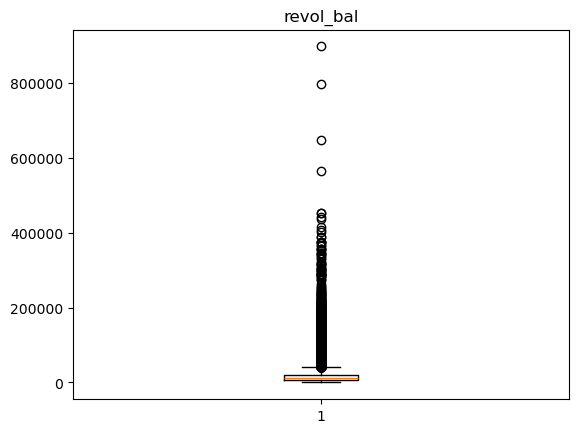

In [275]:

# dti = df_cleaned_copy["dti"].clip(upper=50)

plt.boxplot(df_cleaned_copy["revol_bal"])

plt.title("revol_bal")
# plt.title("DTI Distribution")
plt.show()


In [277]:
df_cleaned_copy["dti"].describe()

count    44006.000000
mean        19.084638
std          9.914293
min          0.000000
25%         12.420000
50%         18.530000
75%         25.310000
max        999.000000
Name: dti, dtype: float64

### Debt-to-Income (DTI) Distribution
DTI measures total monthly debt payments as a percentage of monthly income — 
a core underwriting metric. Outliers above 40 are filtered out as they 
likely represent data entry errors (the dataset contains a max of 999). 
The `showfliers=False` parameter removes extreme values to show the 
true central distribution clearly.

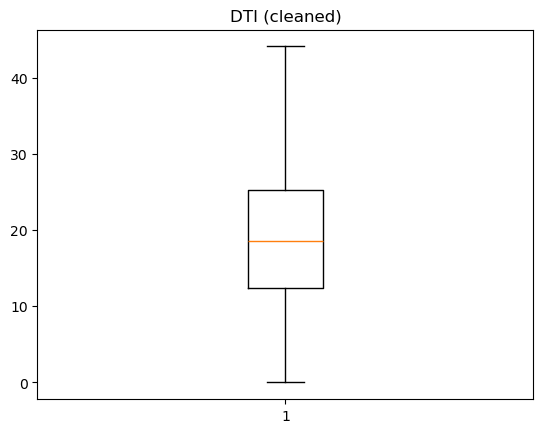

In [280]:
df_cleaned_copy["dti"].describe()
# dti_clean = pd.to_numeric(df_cleaned_copy["dti"], errors="coerce").dropna()
plt.boxplot(df_cleaned_copy["dti"], showfliers=False)
plt.title("DTI (cleaned)")
plt.show()
#dit has a significant variance and outliers

### Home Ownership Distribution
Showing the composition of borrowers by housing status after consolidating 
the rare "ANY" category into "Other". Mortgage holders are the largest group, 
followed by renters. Home ownership is a relevant risk signal
mortgage holders tend to have more stable financial commitments and 
lower default rates than renters.

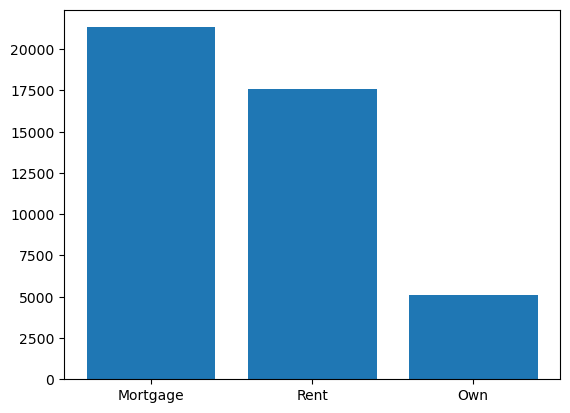

In [283]:
df_cleaned_copy = df_cleaned_copy[df_cleaned_copy['home_ownership'].isin(['Mortgage', 'Rent', 'Own'])]
df_cleaned_copy["home_ownership"].value_counts()

counts = df_cleaned_copy["home_ownership"].value_counts()

plt.bar(counts.index, counts.values)
plt.show()


In [285]:
df_cleaned_copy = df_cleaned_copy[df_cleaned_copy['home_ownership'].isin(['Mortgage', 'Rent', 'Own'])]
df_cleaned_copy["home_ownership"].value_counts()

home_ownership
Mortgage    21325
Rent        17572
Own          5108
Name: count, dtype: int64

### Annual Income Distribution (Log Scale)

Income is heavily right-skewed — a small number of very 
high earners pull the mean well above the median. 
The log scale compresses this long tail to make the 
shape of the true distribution visible.

In [288]:
df_cleaned_copy["annual_inc"].describe()


count    4.400500e+04
mean     7.848170e+04
std      1.023895e+05
min      0.000000e+00
25%      4.700000e+04
50%      6.500000e+04
75%      9.400000e+04
max      9.000000e+06
Name: annual_inc, dtype: float64

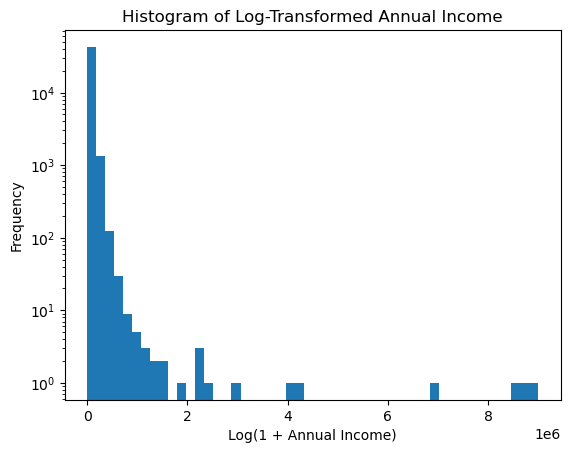

In [290]:

plt.hist(df_cleaned_copy["annual_inc"], bins=50, log=True)
plt.xlabel("Log(1 + Annual Income)")   
plt.ylabel("Frequency")                
plt.title("Histogram of Annual Income (log-scaled frequency)")  
plt.show()

### FICO Score vs Average Interest Rate 
FICO score is the most widely used measure of 
creditworthiness in consumer lending. A clean downward 
slope here would confirm that LendingClub's pricing 
responds to credit quality. The steepness of the decline 
matters: a gradual slope means rates are not adjusting 
aggressively enough to lower FICO scores; 
a steep slope suggests the market is pricing 
credit risk efficiently at this level.

In [293]:
#comparing initial risk to the price of a loan
df_cleaned_copy['fico_avg_bin'] = pd.cut(df_cleaned_copy['fico_avg'], bins=10)
fico_agg = df_cleaned_copy.groupby('fico_avg_bin')['int_rate'].mean().reset_index()
print(fico_agg)

        fico_avg_bin   int_rate
0  (661.814, 680.55]  13.589099
1    (680.55, 699.1]  12.297516
2    (699.1, 717.65]  11.160658
3    (717.65, 736.2]  10.139071
4    (736.2, 754.75]   9.311802
5    (754.75, 773.3]   8.586595
6    (773.3, 791.85]   7.722694
7    (791.85, 810.4]   7.649409
8    (810.4, 828.95]   6.975000
9    (828.95, 847.5]   6.478936


/var/folders/7r/bdd9kf094nn92s5vz4jlh0lw0000gp/T/ipykernel_33969/340134069.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fico_agg = df_cleaned_copy.groupby('fico_avg_bin')['int_rate'].mean().reset_index()


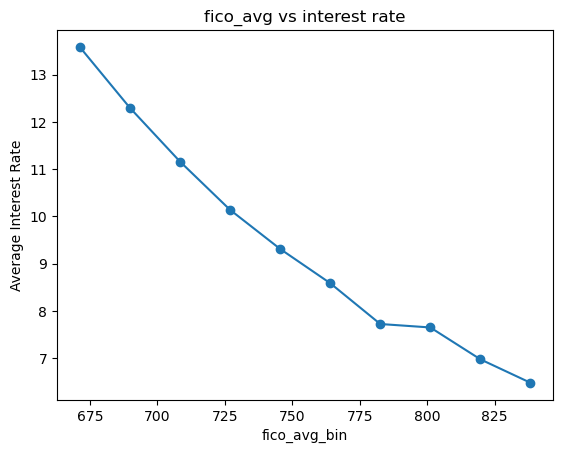

In [295]:

plt.plot(fico_agg['fico_avg_bin'].apply(lambda x: x.mid), fico_agg['int_rate'], marker='o')
plt.xlabel("fico_avg_bin")
plt.ylabel("Average Interest Rate")
plt.title("fico_avg vs interest rate")
plt.show()

### DTI vs Average Interest Rate
Testing whether debt burden is independently reflected 
in pricing. DTI is filtered below 40 to remove 
data entry errors. A rising line would suggest 
lenders charge more to borrowers who are already 
more stretched financially.

/var/folders/7r/bdd9kf094nn92s5vz4jlh0lw0000gp/T/ipykernel_33969/525537084.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['dti_bin'] = pd.cut(df_filtered['dti'], bins=10)
/var/folders/7r/bdd9kf094nn92s5vz4jlh0lw0000gp/T/ipykernel_33969/525537084.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dti_agg = df_filtered.groupby('dti_bin')['int_rate'].mean().reset_index()


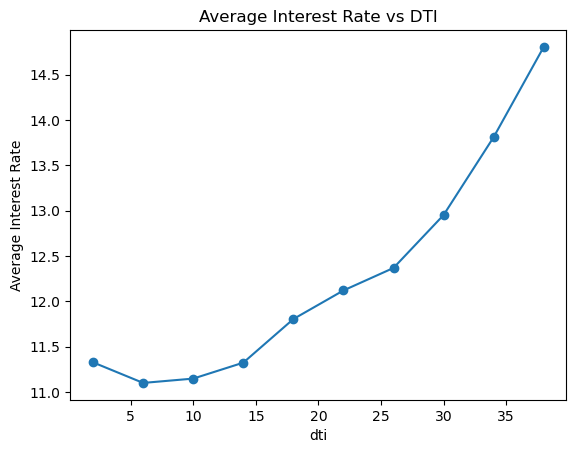

In [298]:
df_filtered = df_cleaned_copy[(df_cleaned_copy["dti"] < 40) & (df_cleaned_copy["int_rate"] < 35)]
df_filtered['dti_bin'] = pd.cut(df_filtered['dti'], bins=10)

# Calculate average interest rate per bin
dti_agg = df_filtered.groupby('dti_bin')['int_rate'].mean().reset_index()

# Plot
plt.plot(dti_agg ['dti_bin'].apply(lambda x: x.mid), dti_agg ['int_rate'], marker='o')
plt.xlabel('dti')
plt.ylabel('Average Interest Rate')
plt.title('Average Interest Rate vs DTI')
plt.show()

### Average Interest Rate by Grade
This graph that rates do rise with grade - the grade system 
is functioning as a broad pricing mechanism. 
However, this is only the starting point. 
The key question the model will later address 
is whether this grade-level pricing is granular enough, 
or whether significant mispricing exists 
*within* each grade band.

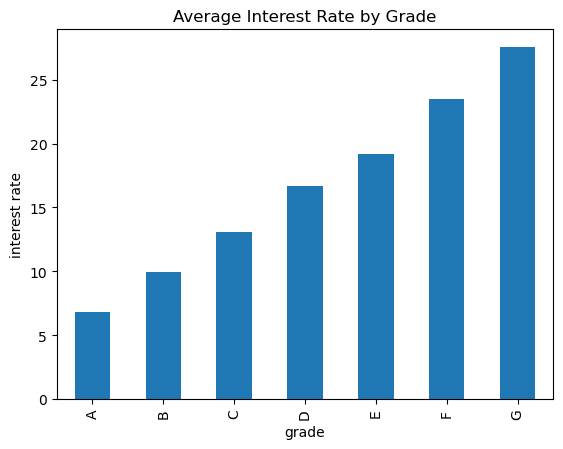

In [301]:
#The Lower the grade, the higher the interest rate

df_cleaned_copy.groupby("grade")["int_rate"].mean().plot(kind="bar")
plt.xlabel("grade")
plt.ylabel("interest rate")
plt.title("Average Interest Rate by Grade")
plt.show()

### Interest Rate Distribution by Grade (Boxplot)

The bar chart shows averages — this boxplot reveals 
the full spread within each grade. Wide boxes indicate 
that two borrowers with the same grade can receive 
very different rates, suggesting some within-grade 
differentiation is already happening. 
Overlapping whiskers between adjacent grades 
(e.g. B and C) would indicate the grade bands 
are not cleanly separated from a pricing perspective — 
which is relevant to the mispricing question.

In [304]:
df_cleaned_copy.boxplot(column="int_rate", by="grade")

<Axes: title={'center': 'int_rate'}, xlabel='grade'>

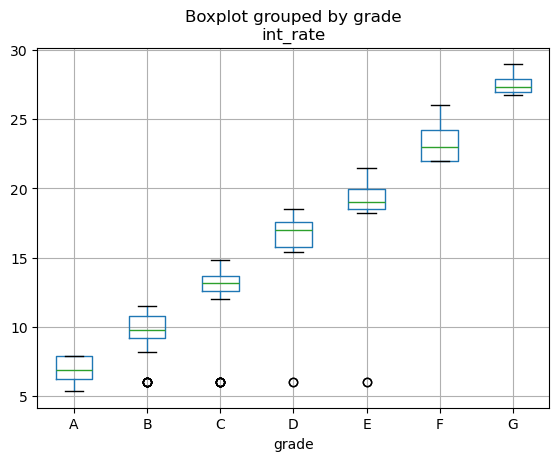

In [306]:
plt.show()

### Loan Status Breakdown by Grade (Crosstab)
Showing the proportion of loans in each outcome 
category for every grade. This is the most direct 
validation of the grading system — Grade A should 
have the lowest charge-off rate and Grade G the highest. 

In [309]:
pd.crosstab(df['grade'], df['loan_status'], normalize='index')

loan_status,Charged Off,Current,Default,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
grade,,,,,,,
A,0.051383,0.025113,0.000000,0.922231,0.000231,0.000000,0.001042
B,0.125524,0.085626,0.000000,0.784526,0.001179,0.000262,0.002883
C,0.197920,0.148112,0.000000,0.644255,0.002136,0.001516,0.006062
D,0.291327,0.161671,0.000000,0.535506,0.003929,0.000728,0.006839
E,0.356407,0.188787,0.000286,0.436785,0.004863,0.001716,0.011156
F,0.442872,0.139535,0.000000,0.396360,0.003033,0.001011,0.017189
G,0.486486,0.121622,0.000000,0.373874,0.009009,0.000000,0.009009


### Default Rate (%) by Grade
The default rate rises consistently from Grade A 
(~5%) to Grade G (~55%) — confirming the grading 
system is a meaningful risk differentiator and 
a strong candidate feature for the model. 
The near-linear step-up also raises the pricing question 
directly: if default risk increases this steeply 
across grades, do interest rates rise at the same pace? 
If not, high-grade borrowers are effectively 
subsidising low-grade ones.

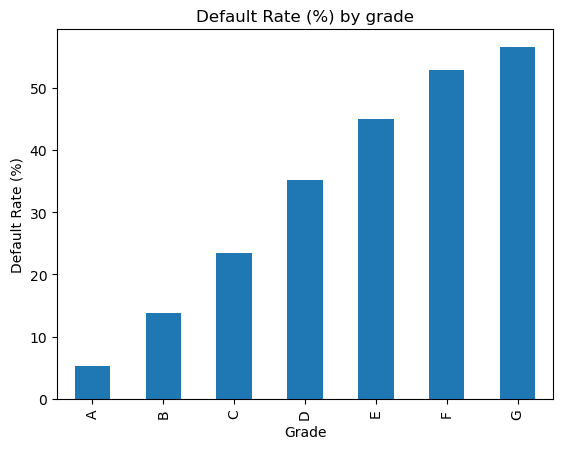

In [312]:
(df_cleaned_copy.groupby("grade")["default"].mean()*100).plot(kind = "bar")
plt.title("Default Rate (%) by grade")
plt.xlabel("Grade")
plt.ylabel("Default Rate (%)")
plt.show()

### Default Rate (%) by Home Ownership
Testing whether home ownership adds independent 
predictive value beyond what grade already captures. 
If renters default at meaningfully higher rates 
than mortgage holders within the same grade band, 
home ownership should be included as a model feature. 

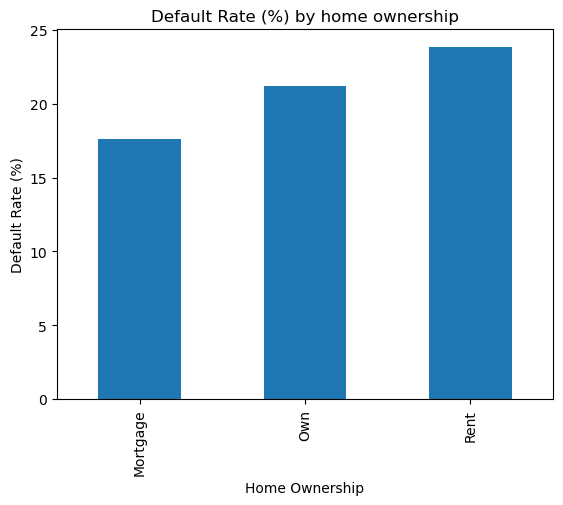

In [315]:
(df_cleaned_copy.groupby("home_ownership")["default"].mean()*100).plot(kind = "bar")

plt.title("Default Rate (%) by home ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate (%)")
plt.show()

### Average Income vs Loan Amount
A basic sanity check confirming that larger loans 
are being taken by higher-income borrowers. The clean positive relationship 
confirms the dataset is behaving as expected 
and validates the logic behind the 
loan-to-income ratio feature.

In [318]:
df_cleaned_copy['loan_bin'] = pd.cut(df_filtered['loan_amnt'], bins=10)

# Calculate average interest rate per bin
loan_agg = df_cleaned_copy.groupby('loan_bin')['annual_inc'].mean().reset_index()
print(loan_agg)

             loan_bin     annual_inc
0     (966.0, 4400.0]   55168.266689
1    (4400.0, 7800.0]   57091.577746
2   (7800.0, 11200.0]   66303.983551
3  (11200.0, 14600.0]   72438.382456
4  (14600.0, 18000.0]   78490.818378
5  (18000.0, 21400.0]   89992.558647
6  (21400.0, 24800.0]   95835.763528
7  (24800.0, 28200.0]  115368.188553
8  (28200.0, 31600.0]  114150.406101
9  (31600.0, 35000.0]  142172.853375


/var/folders/7r/bdd9kf094nn92s5vz4jlh0lw0000gp/T/ipykernel_33969/1587924822.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_agg = df_cleaned_copy.groupby('loan_bin')['annual_inc'].mean().reset_index()


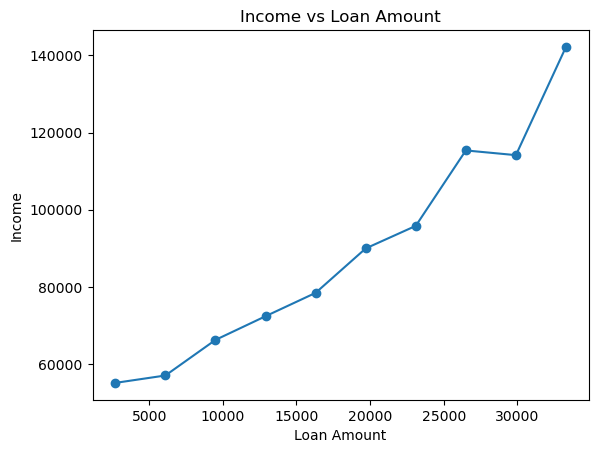

In [320]:
# Plot
plt.plot(loan_agg['loan_bin'].apply(lambda x: x.mid), loan_agg['annual_inc'], marker='o')
plt.xlabel('Loan Amount')
plt.ylabel('Income')
plt.title('Income vs Loan Amount')
plt.show()

### Loan Amount Distribution by Grade (Violin Plot)
Unlike the bar chart which shows averages, 
the violin shape reveals the full distribution 
of loan sizes within each grade. A wide violin 
at high loan amounts for low grades (F, G) would 
be a concern — it would mean riskier borrowers 
are taking disproportionately large loans, 
compounding the credit risk the grade already reflects. 
The width at each point shows how many borrowers 
sit at that loan amount.

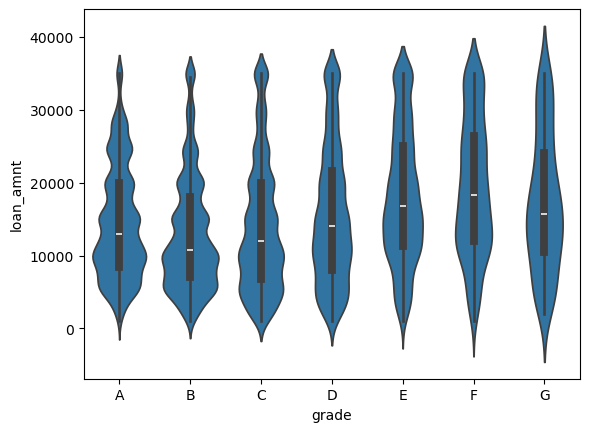

In [323]:
import seaborn as sns

sns.violinplot(x="grade", y="loan_amnt", data=df_cleaned_copy,
               order=['A','B','C','D','E','F','G'])
plt.show()

### Loan-to-Income Ratio by Grade

Validating that the engineered feature behaves 
as expected. If lower-grade borrowers have higher 
loan-to-income ratios, it confirms they are more 
financially stretched

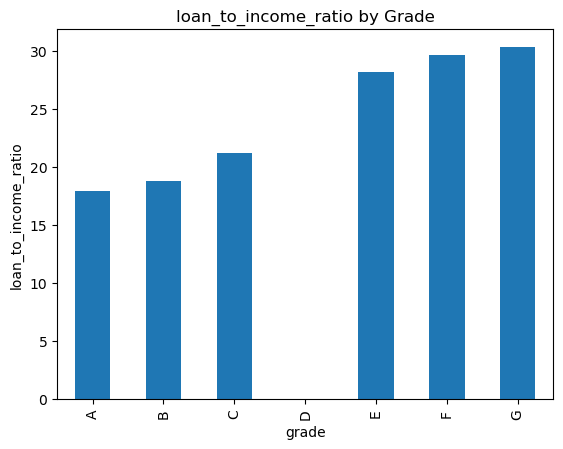

In [326]:
df_cleaned_copy.groupby("grade")["loan_to_income_ratio (%)"].mean().plot(kind="bar")
plt.xlabel("grade")
plt.ylabel("loan_to_income_ratio")
plt.title("loan_to_income_ratio by Grade")
plt.show()

### Feature Correlation Heatmap

Showing pairwise Pearson correlations between all 
numeric features to identify multicollinearity 
before modelling and flag the strongest 
univariate predictors of key variables.

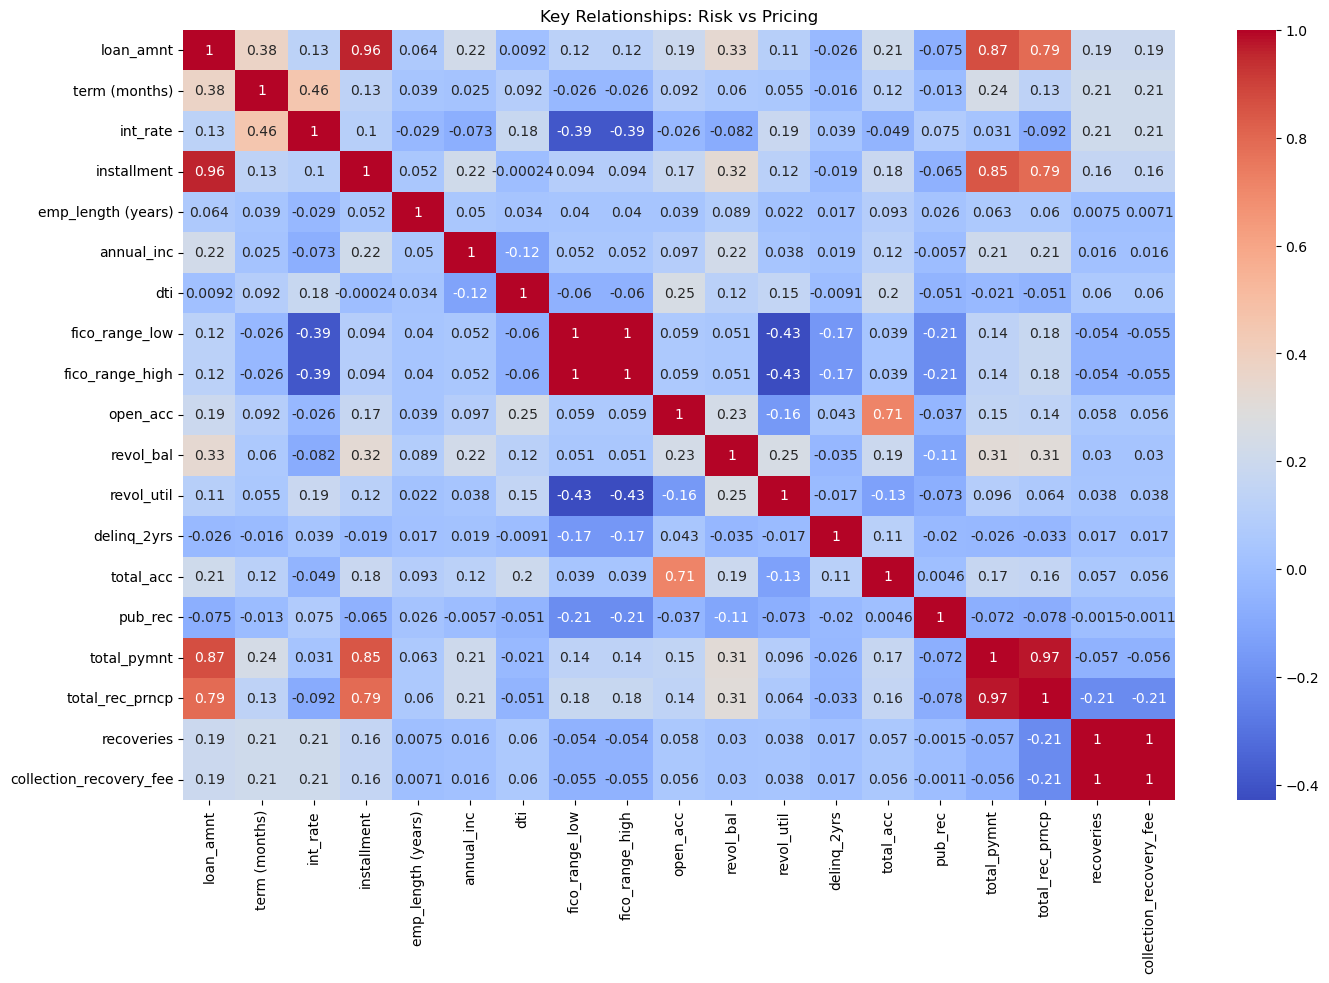

In [329]:
import seaborn as sns
plt.figure(figsize=(16,10))

loan_info = ['loan_amnt', 'term (months)', 'int_rate', 'grade', 'sub_grade', 'installment']
borrower_info = ['emp_title', 'emp_length (years)', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti']
credit_info = ['fico_range_low', 'fico_range_high', 'open_acc', 'revol_bal', 'revol_util', 'delinq_2yrs', 'total_acc', 'pub_rec']
target_variable = ['loan_status']
payment_info = ['total_pymnt', 'total_rec_prncp', 'recoveries', 'collection_recovery_fee']
                

columns= loan_info + borrower_info + credit_info + target_variable + payment_info
sns.heatmap(df_cleaned_copy[columns].select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
#select_dtypes(include="number") keeps only numeric columns (e.g., int, float) and drops everything else.
plt.title("Key Relationships: Risk vs Pricing")
plt.show()



In [331]:
# df_cleaned_copy = df_cleaned_copy.drop('loan_to_income_ratio', axis=1)
df_cleaned_copy.columns

Index(['loan_amnt', 'term (months)', 'int_rate', 'grade', 'sub_grade',
       'installment', 'emp_title', 'emp_length (years)', 'home_ownership',
       'annual_inc', 'verification_status', 'purpose', 'dti', 'fico_range_low',
       'fico_range_high', 'open_acc', 'revol_bal', 'revol_util', 'delinq_2yrs',
       'total_acc', 'pub_rec', 'loan_status', 'total_pymnt', 'total_rec_prncp',
       'recoveries', 'collection_recovery_fee', 'fico_avg', 'default',
       'loan_to_income_ratio (%)', 'fico_avg_bin', 'loan_bin'],
      dtype='object')

In [333]:
df_cleaned_copy.to_csv("cleaned_data.csv", index=False)

In [337]:
import os
print(os.getcwd())

/Users/anaistong/CFG/practice/Specialisation/Lending Club Analysis
